In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score, davies_bouldin_score, pairwise_distances_argmin
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df_scaled = pickle.load(open('data/df_scaled.pkl', 'rb'))
df_clean  = pickle.load(open('data/df_clean.pkl',  'rb'))
scaler    = pickle.load(open('data/scaler.pkl',    'rb'))
print('Data loaded. Shape:', df_scaled.shape)

Data loaded. Shape: (8068, 9)


In [2]:
# Fix any remaining NaN before clustering
if np.isnan(df_scaled).any():
    print('⚠️  NaN detected in df_scaled — applying median imputation...')
    col_medians = np.nanmedian(df_scaled, axis=0)
    nan_indices = np.where(np.isnan(df_scaled))
    df_scaled[nan_indices] = np.take(col_medians, nan_indices[1])
    print('✅ NaN fixed!')
else:
    print('✅ No NaN found — data is clean and ready!')
print('Shape:', df_scaled.shape)

✅ No NaN found — data is clean and ready!
Shape: (8068, 9)


In [3]:
np.random.seed(42)
sample_idx = np.random.choice(len(df_scaled), size=2000, replace=False)
df_sample  = df_scaled[sample_idx]
print('Training sample size:', df_sample.shape)

Training sample size: (2000, 9)


In [4]:
print('Testing quantile values for bandwidth...')
print(f'{"quantile":>10}  {"bandwidth":>11}  {"clusters":>9}')
print('-' * 35)
for q in [0.05, 0.1, 0.15, 0.2, 0.25, 0.3]:
    bw       = estimate_bandwidth(df_sample, quantile=q)
    ms_test  = MeanShift(bandwidth=bw)
    lbl_test = ms_test.fit_predict(df_sample)
    n        = len(set(lbl_test))
    print(f'{q:>10}  {bw:>11.4f}  {n:>9}')

print('\n👉 Pick a quantile that gives 3–8 clusters.')

Testing quantile values for bandwidth...
  quantile    bandwidth   clusters
-----------------------------------
      0.05       2.4484          4
       0.1       2.8510          1
      0.15       3.1148          1
       0.2       3.3170          1
      0.25       3.4909          1
       0.3       3.6438          1

👉 Pick a quantile that gives 3–8 clusters.


In [5]:
QUANTILE  = 0.15   # ← adjust based on output above
bandwidth = estimate_bandwidth(df_sample, quantile=QUANTILE)
print(f'Using bandwidth={bandwidth:.4f}  (quantile={QUANTILE})')

print('Training MeanShift... (may take 1–2 minutes)')
ms = MeanShift(bandwidth=bandwidth)
ms.fit(df_sample)

# Predict on FULL dataset by assigning each point to nearest cluster center
ms_labels  = pairwise_distances_argmin(df_scaled, ms.cluster_centers_)
n_clusters = len(set(ms_labels))

print(f'\n✅ Clusters found: {n_clusters}')
unique, counts = np.unique(ms_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c} customers')

Using bandwidth=3.1148  (quantile=0.15)
Training MeanShift... (may take 1–2 minutes)

✅ Clusters found: 1
  Cluster 0: 8068 customers


In [6]:
# Evaluate on a random sample of 2000 for speed
eval_idx    = np.random.choice(len(df_scaled), size=2000, replace=False)
df_eval     = df_scaled[eval_idx]
labels_eval = ms_labels[eval_idx]

sil = silhouette_score(df_eval, labels_eval) if n_clusters >= 2 else -1
dbs = davies_bouldin_score(df_eval, labels_eval) if n_clusters >= 2 else -1

print('=== MeanShift Evaluation ===')
print(f'Bandwidth           : {bandwidth:.4f}')
print(f'Clusters found      : {n_clusters}')
print(f'Silhouette Score    : {sil:.4f}  (higher = better)')
print(f'Davies-Bouldin Score: {dbs:.4f}  (lower  = better)')

scores = {'algorithm': 'MeanShift', 'n_clusters': n_clusters,
          'silhouette': round(sil, 4), 'davies_bouldin': round(dbs, 4),
          'inertia': 'N/A', 'noise': 0}
pickle.dump(scores,    open('data/meanshift_scores.pkl', 'wb'))
pickle.dump(ms_labels, open('data/meanshift_labels.pkl', 'wb'))
pickle.dump(ms,        open('data/meanshift_model.pkl',  'wb'))
print('\n✅ Scores saved!')

=== MeanShift Evaluation ===
Bandwidth           : 3.1148
Clusters found      : 1
Silhouette Score    : -1.0000  (higher = better)
Davies-Bouldin Score: -1.0000  (lower  = better)

✅ Scores saved!


Variance explained: 41.1%


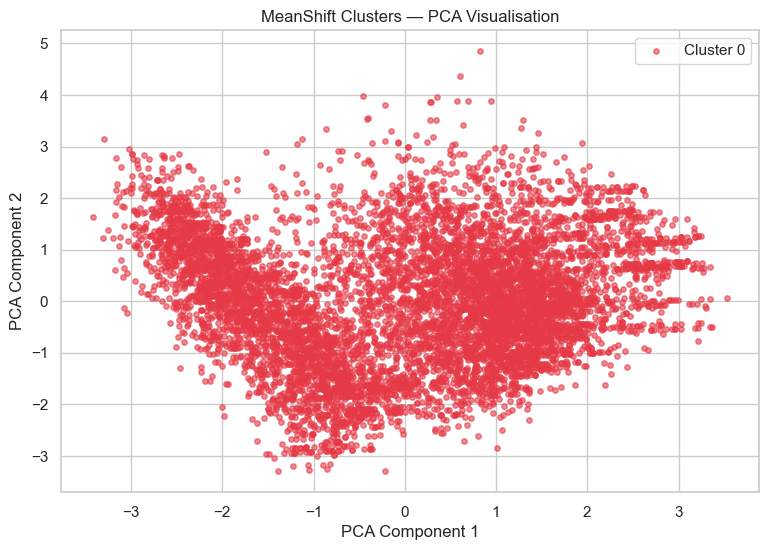

In [7]:
pca    = PCA(n_components=2, random_state=42)
df_pca = pca.fit_transform(df_scaled)
print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

colors = ['#E63946','#457B9D','#2A9D8F','#E9C46A','#F4A261','#264653','#7B2D8B']

plt.figure(figsize=(9, 6))
for i in range(n_clusters):
    mask = ms_labels == i
    plt.scatter(df_pca[mask, 0], df_pca[mask, 1],
                s=15, color=colors[i % len(colors)],
                label=f'Cluster {i}', alpha=0.6)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('MeanShift Clusters — PCA Visualisation')
plt.legend()
plt.savefig('data/meanshift_pca.png', dpi=150, bbox_inches='tight')
plt.show()

=== Cluster Profiles (Mean Values) ===
         Gender  Ever_Married    Age  Graduated  Profession  Work_Experience  \
Cluster                                                                        
0          0.45          0.59  43.47       0.63        2.75             2.47   

         Spending_Score  Family_Size  Var_1  
Cluster                                      
0                  0.55         2.86   4.15  


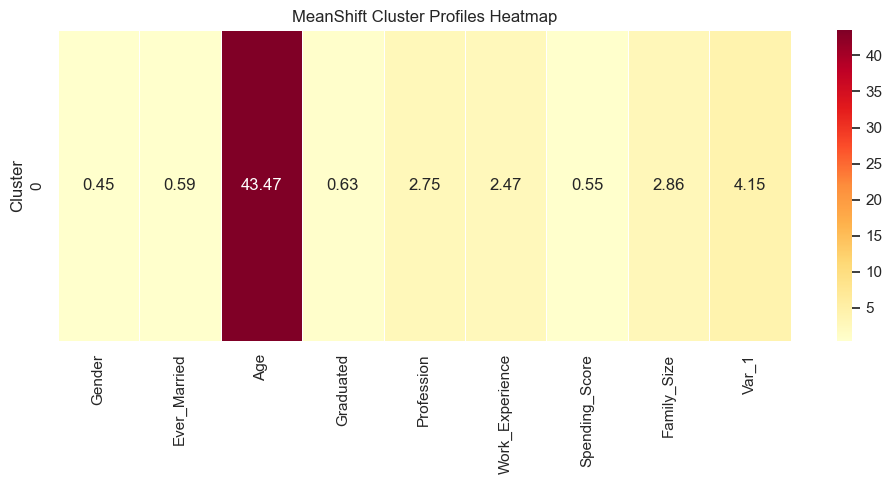

In [8]:
# Cluster profiles
df_result            = df_clean.copy()
df_result['Cluster'] = ms_labels

print('=== Cluster Profiles (Mean Values) ===')
profile = df_result.groupby('Cluster').mean().round(2)
print(profile)

plt.figure(figsize=(10, 5))
sns.heatmap(profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('MeanShift Cluster Profiles Heatmap')
plt.tight_layout()
plt.savefig('data/meanshift_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
print('=' * 55)
print('  MEANSHIFT: Predict Cluster for a New Customer')
print('=' * 55)
print('MeanShift automatically detected clusters — no K needed!\n')
print('Profession codes : 0=Artist, 1=Doctor, 2=Engineer,')
print('                   3=Entertainment, 4=Executive,')
print('                   5=Healthcare, 6=Homemaker,')
print('                   7=Lawyer, 8=Marketing')
print('Var_1 codes      : 0 to 6 (category code)')
print()

age            = float(input('Age (e.g. 30): '))
gender         = float(input('Gender        — Male=0, Female=1: '))
ever_married   = float(input('Ever Married  — No=0, Yes=1: '))
graduated      = float(input('Graduated     — No=0, Yes=1: '))
profession     = float(input('Profession    — (enter code 0–8): '))
work_exp       = float(input('Work Experience (years, e.g. 5): '))
spending_score = float(input('Spending Score — Low=0, Average=1, High=2: '))
family_size    = float(input('Family Size   (e.g. 3): '))
var_1          = float(input('Var_1         — (enter code 0–6): '))

user_data   = np.array([[age, gender, ever_married, graduated,
                          profession, work_exp, spending_score,
                          family_size, var_1]])
user_scaled = scaler.transform(user_data)

# Assign to nearest cluster center
predicted_cluster = pairwise_distances_argmin(user_scaled, ms.cluster_centers_)[0]

profile = df_result.groupby('Cluster').mean().round(2)

print()
print('=' * 55)
print(f'  ✅ Predicted Cluster: Cluster {predicted_cluster}')
print('=' * 55)
print(f'\nAverage profile of Cluster {predicted_cluster}:')
print(profile.loc[predicted_cluster].to_string())
print('\n👉 This customer belongs to the group above.')

  MEANSHIFT: Predict Cluster for a New Customer
MeanShift automatically detected clusters — no K needed!

Profession codes : 0=Artist, 1=Doctor, 2=Engineer,
                   3=Entertainment, 4=Executive,
                   5=Healthcare, 6=Homemaker,
                   7=Lawyer, 8=Marketing
Var_1 codes      : 0 to 6 (category code)



Age (e.g. 30):  20
Gender        — Male=0, Female=1:  1
Ever Married  — No=0, Yes=1:  0
Graduated     — No=0, Yes=1:  1
Profession    — (enter code 0–8):  3
Work Experience (years, e.g. 5):  4
Spending Score — Low=0, Average=1, High=2:  2
Family Size   (e.g. 3):  2
Var_1         — (enter code 0–6):  1



  ✅ Predicted Cluster: Cluster 0

Average profile of Cluster 0:
Gender              0.45
Ever_Married        0.59
Age                43.47
Graduated           0.63
Profession          2.75
Work_Experience     2.47
Spending_Score      0.55
Family_Size         2.86
Var_1               4.15

👉 This customer belongs to the group above.
